<a href="https://colab.research.google.com/github/zainazeem41472/Rice-Leaf-Disease-Classification/blob/main/EnsembleModel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import numpy as np

In [4]:
def build_model_1(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling2D()(x)

    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [5]:
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


def build_model_2(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = MaxPooling2D()(x)

    x = residual_block(x, 64)
    x = MaxPooling2D()(x)

    x = residual_block(x, 128)
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [6]:
def attention_block(x):
    attn = Conv2D(1, (1,1), activation='sigmoid')(x)
    return Multiply()([x, attn])


def build_model_3(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling2D()(x)

    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = attention_block(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = attention_block(x)
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [7]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = "/content/drive/MyDrive/RiceLeafDisease12class/train"
VAL_DIR   = "/content/drive/MyDrive/RiceLeafDisease12class/validation"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11996 images belonging to 12 classes.
Found 1049 images belonging to 12 classes.


In [9]:
num_classes = train_generator.num_classes
print("Number of classes:", num_classes)

Number of classes: 12


In [10]:
input_shape = (224,224,3)
num_classes = train_generator.num_classes

model1 = compile_model(build_model_1(input_shape, num_classes))
model2 = compile_model(build_model_2(input_shape, num_classes))
model3 = compile_model(build_model_3(input_shape, num_classes))

In [11]:
model1.fit(train_generator, validation_data=val_generator, epochs=50)
model2.fit(train_generator, validation_data=val_generator, epochs=50)
model3.fit(train_generator, validation_data=val_generator, epochs=50)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5374s 14s/step - accuracy: 0.2490 - loss: 2.0696 - val_accuracy: 0.2908 - val_loss: 1.6922
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 222s 593ms/step - accuracy: 0.4502 - loss: 1.5453 - val_accuracy: 0.4824 - val_loss: 1.4253
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 230s 612ms/step - accuracy: 0.5265 - loss: 1.3734 - val_accuracy: 0.5310 - val_loss: 1.2747
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 255s 593ms/step - accuracy: 0.5687 - loss: 1.2384 - val_accuracy: 0.5710 - val_loss: 1.2250
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 222s 593ms/step - accuracy: 0.6067 - loss: 1.1427 - val_accuracy: 0.5968 - val_loss: 1.1296
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 235s 625ms/step - accuracy: 0.6304 - loss: 1.0752 - val_accuracy: 0.6692 - val_loss: 1.0015
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 229s 610ms/step - accuracy: 0.6466 - loss: 1.0232 - val_accuracy: 0.6387 - val_loss: 0.9839
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 229s 610ms/step - accuracy: 0

In [12]:
model1.save("model1.h5")
model2.save("model2.h5")
model3.save("model3.h5")

In [13]:
def ensemble_predict(models, generator):
    preds = []

    for model in models:
        pred = model.predict(generator)
        preds.append(pred)

    preds = np.array(preds)

    # Average predictions
    final_pred = np.mean(preds, axis=0)

    return np.argmax(final_pred, axis=1)

In [14]:
y_pred = ensemble_predict([model1, model2, model3], val_generator)

from sklearn.metrics import accuracy_score
y_true = val_generator.classes

print("Ensemble Accuracy:", accuracy_score(y_true, y_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 323ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 342ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 324ms/step
Ensemble Accuracy: 0.9351763584366063


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[88  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 88  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 79  0  1  0  0  0  1  0  0  0]
 [ 0  0  0 88  0  0  0  0  0  0  0  0]
 [ 2  0  0  0 86  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 86  0  0  0  0  2  0]
 [ 0  0  0  1  0  1 64  1  0 14  0  7]
 [ 0  0  0  0  0  0  3 75  0 10  0  0]
 [ 0  1  1  4  0  0  0  0 81  1  0  0]
 [ 1  0  0  0  0  0  7  3  0 77  0  0]
 [ 1  0  0  0  0  0  0  0  0  0 83  4]
 [ 0  0  0  0  0  0  0  0  0  2  0 86]]


In [16]:
from google.colab import files

uploaded = files.upload()

Saving leaf blast.jpeg to leaf blast.jpeg


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [18]:
class_names = list(train_generator.class_indices.keys())

In [19]:
pred = model1.predict(img_array)
class_id = np.argmax(pred)
confidence = np.max(pred)

print("Prediction:", class_names[class_id])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
Prediction: Ragged Stunt Virus
Confidence: 0.8697487


In [20]:
pred1 = model1.predict(img_array)
pred2 = model2.predict(img_array)
pred3 = model3.predict(img_array)

# Average predictions
final_pred = (pred1 + pred2 + pred3) / 3

class_id = np.argmax(final_pred)
confidence = np.max(final_pred)

print("Ensemble Prediction:", class_names[class_id])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
Ensemble Prediction: Ragged Stunt Virus
Confidence: 0.6066622


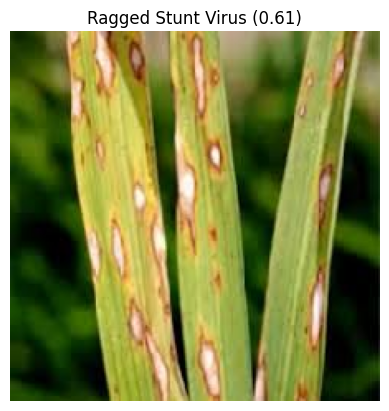

In [21]:
plt.imshow(img)
plt.title(f"{class_names[class_id]} ({confidence:.2f})")
plt.axis('off')
plt.show()

In [22]:
import numpy as np

def ensemble_predict(models, generator):
    preds = []

    for model in models:
        pred = model.predict(generator)
        preds.append(pred)

    preds = np.array(preds)

    # Average predictions
    final_pred = np.mean(preds, axis=0)

    return np.argmax(final_pred, axis=1)

# Predictions
y_pred = ensemble_predict([model1, model2, model3], val_generator)

# True labels
y_true = val_generator.classes

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 318ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 324ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step


In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9351763584366063


In [24]:
from sklearn.metrics import classification_report

class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

                       precision    recall  f1-score   support

                Hispa       0.96      1.00      0.98        88
   Ragged Stunt Virus       0.99      1.00      0.99        88
           Sheath Rot       0.99      0.98      0.98        81
             Stem Rot       0.95      1.00      0.97        88
               Tungro       0.99      0.98      0.98        88
bacterial_leaf_blight       0.99      0.98      0.98        88
           brown_spot       0.86      0.73      0.79        88
              healthy       0.95      0.85      0.90        88
      irrelevant_pics       0.99      0.92      0.95        88
           leaf_blast       0.74      0.88      0.80        88
           leaf_scald       0.98      0.94      0.96        88
    narrow_brown_spot       0.89      0.98      0.93        88

             accuracy                           0.94      1049
            macro avg       0.94      0.94      0.94      1049
         weighted avg       0.94      0.94      0.94 

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[88  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 88  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 79  0  1  0  0  0  1  0  0  0]
 [ 0  0  0 88  0  0  0  0  0  0  0  0]
 [ 2  0  0  0 86  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 86  0  0  0  0  2  0]
 [ 0  0  0  1  0  1 64  1  0 14  0  7]
 [ 0  0  0  0  0  0  3 75  0 10  0  0]
 [ 0  1  1  4  0  0  0  0 81  1  0  0]
 [ 1  0  0  0  0  0  7  3  0 77  0  0]
 [ 1  0  0  0  0  0  0  0  0  0 83  4]
 [ 0  0  0  0  0  0  0  0  0  2  0 86]]


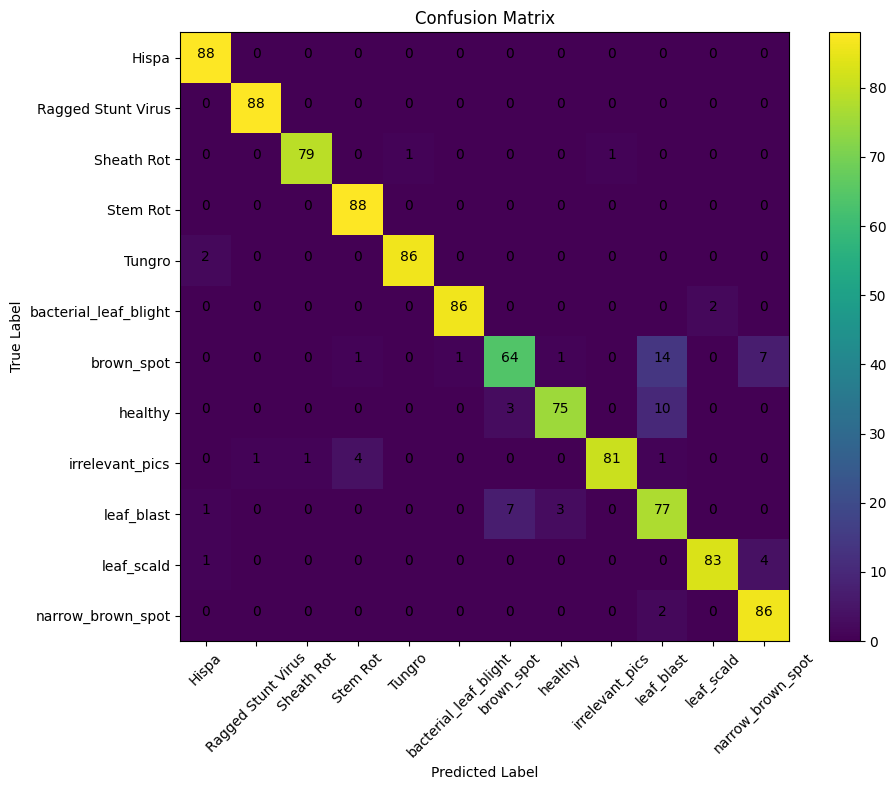

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 color="black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()